# Setup and Imports

In [1]:
import importlib
import src.data_loader

importlib.reload(src.data_loader)

<module 'src.data_loader' from '/Users/szymonzalewski/Documents/project-milestone-p2-group2/src/data_loader.py'>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import os

from src.data_loader import (
    load_wikispeedia_file,
    load_shortest_path_matrix,
    get_article_text,
    get_article_html,
    find_absolute_link_position_from_df
)
from src.feature_extractor import FeatureExtractor, EMBEDDING_DIM
from src.evaluation import calculate_mrr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load .tsv and .txt files

In [21]:
# Load all files from wikispeedia_paths-and-graph

# 1. Articles
articles_df = load_wikispeedia_file(
    "articles.tsv",
    columns=["article_name"]
)
articles_df["article_id"] = articles_df["article_name"]

print("Articles:", articles_df.shape)
display(articles_df.head())

# 2. Categories
categories_df = load_wikispeedia_file(
    "categories.tsv",
    columns=["article", "category"]
)
print("Categories:", categories_df.shape, "\n")
display(categories_df.head())

# 3. Links
links_df = load_wikispeedia_file(
    "links.tsv",
    columns=["source", "target"]
)
print("Links:", links_df.shape)
display(links_df.head())

# 4. Finished paths
paths_finished_df = load_wikispeedia_file(
    "paths_finished.tsv",
    columns=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
)
print("Finished paths:", paths_finished_df.shape)
display(paths_finished_df.head())

# 5. Unfinished paths
paths_unfinished_df = load_wikispeedia_file(
    "paths_unfinished.tsv",
    columns=["session_id", "timestamp", "session_time", "path", "rating", "type"]
)
print("Unfinished paths:", paths_unfinished_df.shape)
display(paths_unfinished_df.head())

# 6. Shortest path matrix
dist_matrix = load_shortest_path_matrix()
print(dist_matrix.shape)

Loading: ./data/wikispeedia_paths-and-graph/articles.tsv
Articles: (4604, 2)


,article_name,article_id
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin
1,Åland,Åland
2,Édouard_Manet,Édouard_Manet
3,Éire,Éire
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts


Loading: ./data/wikispeedia_paths-and-graph/categories.tsv
Categories: (5204, 2) 



,article,category
0,Áedán_mac_Gabráin,subject.History.British_History.British_Histor...
1,Áedán_mac_Gabráin,subject.People.Historical_figures
2,Åland,subject.Countries
3,Åland,subject.Geography.European_Geography.European_...
4,Édouard_Manet,subject.People.Artists


Loading: ./data/wikispeedia_paths-and-graph/links.tsv
Links: (119882, 2)


...

Loading: ./data/wikispeedia_paths-and-graph/paths_finished.tsv
Finished paths: (51318, 5)


,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3


Loading: ./data/wikispeedia_paths-and-graph/paths_unfinished.tsv
Unfinished paths: (24875, 6)


,session_id,timestamp,session_time,path,rating,type
0,2426091a53125110,1297054935,1804,Obi-Wan_Kenobi,Microsoft,timeout
1,26141fd878806294,1297055651,1805,Julius_Caesar,Caracas,timeout
2,2b015fb8181c48f2,1297090819,1818,Malawi;Democracy;Alexander_the_Great,First_Crusade,timeout
3,53a53bc244e08a6a,1297094761,49,Paraguay,Mount_St._Helens,restart
4,53a53bc244e08a6a,1297099105,1808,Paraguay;Bolivia,Mount_St._Helens,timeout


Loading distance matrix...
(4604, 4604)


## Load plain article text & html text into articles dataframe

In [5]:
# load plain article text into articles dataframe as new column
articles_df["plaintext"] = articles_df["article_name"].apply(lambda x: get_article_text(x))

# add column for the plaintext text length
articles_df["plaintext_length"] = articles_df["plaintext"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

# load html files into articles dataframe as new column
articles_df["html_content"] = articles_df["article_name"].apply(
    lambda x: get_article_html(x)
)

### Load html text for 5 articles with errors manually 

In [8]:
# load data for the 5 missing ones manually
manual_fixes = {
    "Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/d/Directdebit.htm"
    ,"Donation": "./data/wikispeedia_articles_html/wpcd/wp/d/Donation.htm"
    ,"Friend_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/f/Friend_Directdebit.htm"
    ,"Sponsorship_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/s/Sponsorship_Directdebit.htm"
    ,"Wowpurchase": "./data/wikispeedia_articles_html/wpcd/wp/w/Wowpurchase.htm"
}

from pathlib import Path

for name, path in manual_fixes.items():
    file_path = Path(path)
    try:
        html_text = file_path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        html_text = file_path.read_text(encoding="latin-1")
    articles_df.loc[articles_df["article_name"] == name, "html_content"] = html_text
    print(f"✅ Loaded {name}")

# Check if we have empty rows in html_content column
nan_html_content = articles_df[articles_df["html_content"].isna()]
print(f"Amount articles with missing html content: {len(nan_html_content)}")
display(nan_html_content)

✅ Loaded Directdebit
✅ Loaded Donation
✅ Loaded Friend_Directdebit
✅ Loaded Sponsorship_Directdebit
✅ Loaded Wowpurchase
Amount articles with missing html content: 4599


,article_name,article_id,plaintext,plaintext_length,html_content
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,NaN
1,Åland,Åland,#copyright\n\nÅland\n\n2007 Schools Wikiped...,17238,NaN
2,Édouard_Manet,Édouard_Manet,#copyright\n\nÉdouard Manet\n\n2007 Schools...,18996,NaN
3,Éire,Éire,#copyright\n\nÉire\n\n2007 Schools Wikipedi...,13083,NaN
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts,#copyright\n\nÓengus I of the Picts\n\n2007...,12944,NaN
...,...,...,...,...,...
4599,Zionism,Zionism,#copyright\n\nZionism\n\n2007 Schools Wikip...,62086,NaN
4600,Zirconium,Zirconium,#copyright\n\nZirconium\n\n2007 Schools Wik...,13253,NaN
4601,Zoroaster,Zoroaster,#copyright\n\nZoroaster\n\n2007 Schools Wik...,19726,NaN
4602,Zuid-Gelders,Zuid-Gelders,#copyright\n\nZuid-Gelders\n\n2007 Schools ...,2341,NaN


### Add column with length of html text

In [9]:
# add column for the html text length
articles_df["html_length"] = articles_df["html_content"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

display(articles_df.sort_values(by="html_length", ascending=True))

,article_name,article_id,plaintext,plaintext_length,html_content,html_length
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,NaN,0
3058,Oligocene,Oligocene,#copyright\n\nOligocene\n\n2007 Schools Wik...,5495,NaN,0
3059,Olive_oil,Olive_oil,#copyright\n\nOlive oil\n\n2007 Schools Wik...,23251,NaN,0
3060,Oliver_Cromwell,Oliver_Cromwell,#copyright\n\nOliver Cromwell\n\n2007 Schoo...,51184,NaN,0
3061,Oliver_Twist,Oliver_Twist,#copyright\n\nOliver Twist\n\n2007 Schools ...,9459,NaN,0
...,...,...,...,...,...,...
4545,Wowpurchase,Wowpurchase,[1x1.gif] [1x1.gi...,871,"<html>\n<head>\n<meta name=""keywords"" content=...",3118
1231,Donation,Donation,[1x1.gif] [1x1.gi...,2540,"<html>\n<head>\n<meta name=""keywords"" content=...",18642
1210,Directdebit,Directdebit,[1x1.gif] [1x1.gi...,3791,"<html>\n<head>\n<meta name=""keywords"" content=...",20688
1600,Friend_Directdebit,Friend_Directdebit,[1x1.gif] [1x1.gi...,3946,"<html>\n<head>\n<meta name=""keywords"" content=...",20894


## Add two columns for indegree and outdegree of each article

In [10]:
# expand articles dataframe with column for outdegree and indegree

# Count how often each article appears as a source (outdegree)
outdegree = links_df["source"].value_counts().rename("outdegree")

# Count how often each article appears as a target (indegree)
indegree = links_df["target"].value_counts().rename("indegree")

# Merge both counts into your articles dataframe
articles_df = articles_df.drop(columns=["outdegree", "indegree"], errors="ignore")
articles_df = (
    articles_df
    .merge(outdegree, how="left", left_on="article_name", right_index=True)
    .merge(indegree, how="left", left_on="article_name", right_index=True)
)
# articles_df = articles_df.drop(columns=['outdegree_x', 'indegree_x', "outdegree_y", "indegree_y"])

# fill NaN values with 0 (for articles that have no links or are isolated)
articles_df[["outdegree", "indegree"]] = articles_df[["outdegree", "indegree"]].fillna(0).astype(int)


# check if we have articles with either 0 outdegree or indegree
isolated_df = articles_df[(articles_df["outdegree"] == 0) | (articles_df["indegree"] == 0)]

print(f"Amount articles with 0 indegree or outdegree: {len(isolated_df)}")
display(isolated_df)


Amount articles with 0 indegree or outdegree: 474


,article_name,article_id,plaintext,plaintext_length,html_content,html_length,outdegree,indegree
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,NaN,0,11,0
1,Åland,Åland,#copyright\n\nÅland\n\n2007 Schools Wikiped...,17238,NaN,0,19,0
2,Édouard_Manet,Édouard_Manet,#copyright\n\nÉdouard Manet\n\n2007 Schools...,18996,NaN,0,20,0
3,Éire,Éire,#copyright\n\nÉire\n\n2007 Schools Wikipedi...,13083,NaN,0,8,0
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts,#copyright\n\nÓengus I of the Picts\n\n2007...,12944,NaN,0,10,0
...,...,...,...,...,...,...,...,...
4566,Yellowhammer,Yellowhammer,#copyright\n\nYellowhammer\n\n2007 Schools ...,2361,NaN,0,13,0
4575,Yotsuya_Kaidan,Yotsuya_Kaidan,#copyright\n\nYotsuya Kaidan\n\n2007 School...,10727,NaN,0,2,0
4576,You're_Still_the_One,You're_Still_the_One,#copyright\n\nYou're Still the One\n\n2007 ...,13571,NaN,0,2,0
4580,"Yungay,_Peru","Yungay,_Peru","#copyright\n\nYungay, Peru\n\n2007 Schools ...",2233,NaN,0,4,0


## Add the position of the links in the html files to the links dataframe

In [11]:
# get absolute position of links
articles_lookup = dict(zip(articles_df["article_name"], articles_df["html_content"]))

links_df["link_position_absolute"] = links_df.apply(
    lambda row: find_absolute_link_position_from_df(row, articles_lookup)
    ,axis=1
)


# get relative position of the links
links_df["html_length"] = links_df["source"].map(
    articles_df.set_index("article_name")["html_length"]
)

# compute relative position
links_df["link_position_relative"] = (
    links_df["link_position_absolute"] / links_df["html_length"]
).where(links_df["html_length"] > 0)


In [12]:
# check links dataframe for link positions
print("Sort absolute link position ascending")
display(links_df.sort_values(by="link_position_absolute", ascending=True))

# check how many links couldn't be found 
print("Check for link position that couldn't be found")
nan_links_link_position = links_df[links_df["link_position_absolute"].isna()]
display(nan_links_link_position)

# check the relative position
print("Sort relative link position ascending")
display(links_df.sort_values(by="link_position_relative"))

Sort absolute link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
41579,Friend_Directdebit,Directdebit,1491.0,20894,0.071360
101642,Sponsorship_Directdebit,Directdebit,1589.0,21191,0.074985
101643,Sponsorship_Directdebit,Friend_Directdebit,1589.0,21191,0.074985
0,Áedán_mac_Gabráin,Bede,NaN,0,NaN
1,Áedán_mac_Gabráin,Columba,NaN,0,NaN
...,...,...,...,...,...
119877,Zulu,South_Africa,NaN,0,NaN
119878,Zulu,Swaziland,NaN,0,NaN
119879,Zulu,United_Kingdom,NaN,0,NaN
119880,Zulu,Zambia,NaN,0,NaN


Check for link position that couldn't be found


,source,target,link_position_absolute,html_length,link_position_relative
0,Áedán_mac_Gabráin,Bede,NaN,0,NaN
1,Áedán_mac_Gabráin,Columba,NaN,0,NaN
2,Áedán_mac_Gabráin,Dál_Riata,NaN,0,NaN
3,Áedán_mac_Gabráin,Great_Britain,NaN,0,NaN
4,Áedán_mac_Gabráin,Ireland,NaN,0,NaN
...,...,...,...,...,...
119877,Zulu,South_Africa,NaN,0,NaN
119878,Zulu,Swaziland,NaN,0,NaN
119879,Zulu,United_Kingdom,NaN,0,NaN
119880,Zulu,Zambia,NaN,0,NaN


Sort relative link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
41579,Friend_Directdebit,Directdebit,1491.0,20894,0.071360
101642,Sponsorship_Directdebit,Directdebit,1589.0,21191,0.074985
101643,Sponsorship_Directdebit,Friend_Directdebit,1589.0,21191,0.074985
0,Áedán_mac_Gabráin,Bede,NaN,0,NaN
1,Áedán_mac_Gabráin,Columba,NaN,0,NaN
...,...,...,...,...,...
119877,Zulu,South_Africa,NaN,0,NaN
119878,Zulu,Swaziland,NaN,0,NaN
119879,Zulu,United_Kingdom,NaN,0,NaN
119880,Zulu,Zambia,NaN,0,NaN


We have two links where the position cannot be determined -> We have to decide how to treat those entries

# Data loading and initial descriptive Analysis

In [13]:
print("--- Descriptive Analysis ---")
print("--- About Articles and Links ---")

print(f"Total articles (nodes): {len(articles_df)}")
print(f"Total links (edges): {len(links_df)}")

paths_finished_df['path_length'] = paths_finished_df['path'].apply(lambda x: len(x.split(';')))
print(f"\n--- Path Length Statistics ---")
print(paths_finished_df['path_length'].describe())

--- Descriptive Analysis ---
--- About Articles and Links ---
Total articles (nodes): 4604
Total links (edges): 119882

--- Path Length Statistics ---
count    51318.000000
mean         6.757434
std          4.680718
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        435.000000
Name: path_length, dtype: float64


--- About finished paths ---


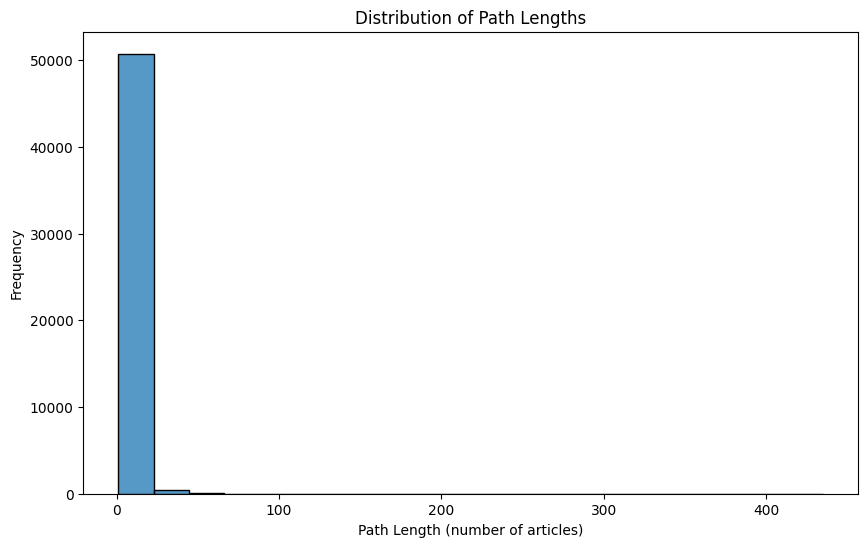

In [49]:
print("--- About finished paths ---")

plt.figure(figsize=(10, 6))
sns.histplot(paths_finished_df['path_length'], kde=False, bins=20)
plt.title('Distribution of Path Lengths')
plt.xlabel('Path Length (number of articles)')
plt.ylabel('Frequency')
plt.show()

# Pre-computation and Setup

In [14]:
extractor = FeatureExtractor()

article_id_to_index = {
    article_id: index 
    for index, article_id in enumerate(articles_df['article_id'])
}

article_id_to_name = pd.Series(
    articles_df.article_name.values, 
    index=articles_df.article_id
).to_dict()

article_name_to_id = pd.Series(
    articles_df.article_id.values,
    index=articles_df.article_name
).to_dict()

links_map = links_df.groupby('source')['target'].apply(list).to_dict()
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

embedding_map = {}
for article_id in tqdm(articles_df['article_id'], desc="Generating Embeddings"):
    article_name = article_id_to_name.get(article_id)
    if article_name:
        text = get_article_text(article_name)
        embedding_map[article_id] = extractor.get_text_embedding(text, strategy='first_para')
    else:
        embedding_map[article_id] = np.zeros(EMBEDDING_DIM)

print("All embeddings are pre-computed and cached.")

Building graph for PageRank and Out-Degree...
Calculating PageRank...
Calculating Out-Degree...
Graph feature maps created.


Generating Embeddings:   0%|          | 0/4604 [00:00<?, ?it/s]

Loading SentenceTransformer model: all-MiniLM-L6-v2...
Model loaded successfully.


Generating Embeddings: 100%|██████████| 4604/4604 [00:38<00:00, 120.36it/s]

All embeddings are pre-computed and cached.



Data Pipeline: Creating the Feature Dataset

In [17]:
def create_feature_dataset(
    paths_subset_df, 
    links_map, 
    embedding_map, 
    dist_matrix, 
    article_id_to_index, 
    pagerank_map, 
    out_degree_map, 
    extractor
):
    X_features = []
    y_labels = []
    query_groups = []
    
    EMBEDDING_DIM = 384
    
    for row in tqdm(paths_subset_df.itertuples(), total=len(paths_subset_df), desc="Processing Paths"):
        path_articles = row.path.split(';')
        goal_id = path_articles[-1]

        for i in range(len(path_articles) - 1):
            source_id = path_articles[i]
            positive_target_id = path_articles[i+1]

            query_id = f"{row.Index}_{i}"

            all_candidates = links_map.get(source_id, [])
            if not all_candidates:
                continue

            emb_source = embedding_map.get(source_id, np.zeros(EMBEDDING_DIM))
            emb_goal = embedding_map.get(goal_id, np.zeros(EMBEDDING_DIM))
            source_idx = article_id_to_index.get(source_id, -1)
            goal_idx = article_id_to_index.get(goal_id, -1)
            
            if source_idx == -1 or goal_idx == -1:
                continue

            for candidate_id in all_candidates:
                if candidate_id not in article_id_to_index:
                    continue

                is_positive = 1 if (candidate_id == positive_target_id) else 0

                emb_candidate = embedding_map.get(candidate_id, np.zeros(EMBEDDING_DIM))
                candidate_idx = article_id_to_index.get(candidate_id, -1)

                sem_features = extractor.get_semantic_features(emb_source, emb_candidate, emb_goal)

                path_features = extractor.get_shortest_path_features(source_idx, candidate_idx, goal_idx, dist_matrix)

                topo_features = extractor.get_topology_features(candidate_id, pagerank_map, out_degree_map)

                all_features = {**sem_features, **path_features, **topo_features}

                X_features.append(all_features)
                y_labels.append(is_positive)
                query_groups.append(query_id)

    X_df = pd.DataFrame(X_features)
    y_series = pd.Series(y_labels, name="is_positive")
    query_series = pd.Series(query_groups, name="query_id")
    
    return X_df, y_series, query_series

## Splitting Data and Running the Pipeline

In [18]:
train_paths_df, val_paths_df = train_test_split(
    paths_finished_df, 
    test_size=0.2, 
    random_state=42
)

print(f"Training paths: {len(train_paths_df)}")
print(f"Validation paths: {len(val_paths_df)}")

print("\nGenerating training data...")
X_train_df, y_train, q_train = create_feature_dataset(
    train_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\nGenerating validation data...")
X_val_df, y_val, q_val = create_feature_dataset(
    val_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\n--- Feature Dataset Shapes ---")
print(f"X_train: {X_train_df.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val_df.shape}, y_val: {y_val.shape}")

print("\n--- Example Features ---")
display(X_train_df.head())

print("\n--- Target Distribution (Train) ---")
print(y_train.value_counts(normalize=True))

Training paths: 41054
Validation paths: 10264

Generating training data...


Processing Paths: 100%|██████████| 41054/41054 [47:24<00:00, 14.43it/s]  



Generating validation data...


Processing Paths: 100%|██████████| 10264/10264 [11:43<00:00, 14.59it/s]



--- Feature Dataset Shapes ---
X_train: (14057674, 7), y_train: (14057674,)
X_val: (3514330, 7), y_val: (3514330,)

--- Example Features ---


,sim_source_candidate,sim_candidate_goal,dist_source_goal,dist_candidate_goal,is_closer,pagerank,out_degree
0,1.0,1.0,3.0,2.0,1,0.002362,93.0
1,1.0,1.0,3.0,3.0,0,0.000485,21.0
2,1.0,1.0,3.0,2.0,1,0.002883,29.0
3,1.0,1.0,3.0,3.0,0,0.001169,37.0
4,1.0,1.0,3.0,3.0,0,0.001214,21.0



--- Target Distribution (Train) ---
is_positive
0    0.985248
1    0.014752
Name: proportion, dtype: float64


## Model training

In [19]:
X_train_df.replace([np.inf, -np.inf], 1000, inplace=True)
X_val_df.replace([np.inf, -np.inf], 1000, inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)

print("Training Proof of Concept model (Logistic Regression)...")
model_poc = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_poc.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'coef': model_poc.coef_[0]
}).sort_values('coef', ascending=False)

print("\n--- Feature Importance (Model Coefficients) ---")
display(feature_importance)

Training Proof of Concept model (Logistic Regression)...

--- Feature Importance (Model Coefficients) ---


,feature,coef
2,dist_source_goal,3.433345
5,pagerank,0.322695
4,is_closer,0.161571
0,sim_source_candidate,0.000000
1,sim_candidate_goal,0.000000
6,out_degree,-0.210940
3,dist_candidate_goal,-6.948091


## Evaluation

In [20]:
print("Calculating Mean Reciprocal Rank (MRR) on validation set...")

mrr_score = calculate_mrr(
    model=model_poc,
    X_val=X_val_scaled,
    y_val=y_val,
    query_groups=q_val
)

print("\n" + "="*30)
print(f"   Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
print("="*30)

Calculating Mean Reciprocal Rank (MRR) on validation set...

   Mean Reciprocal Rank (MRR): 0.4556


# TODO Create results summary and define next steps for P3 Milestone